In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import osipy

## Step 1 Load example data from dicom

In [76]:
from osipy.common.io import discover_dicom, load_dicom_series

series = discover_dicom("C://Temp//ISMRM2026_demo_DCE")
# load DCE data
dce_data = load_dicom_series(
    next(s for s in series if s.role_hint == "dynamic"),
    modality="dce",
)

print(f"Shape DCE: {dce_data.shape}")  # (x, y, z, t)
print(f"TR DCE: {dce_data.acquisition_params.tr} ms")
print(f"Flip angle DCE: {dce_data.acquisition_params.flip_angle}")

# DCE timing
n_timepoints = dce_data.shape[-1]
temporal_resolution = 4.7  # seconds between frames
time = np.arange(n_timepoints) * temporal_resolution

# load vfa data
vfa_data = load_dicom_series([s for s in series if s.role_hint == "vfa"])
print(f"Shape VFA: {vfa_data.shape}")  # (x, y, z, t)
print(f"TR VFA: {vfa_data.acquisition_params.tr} ms")
print(f"Flip angles VFA: {vfa_data.acquisition_params.flip_angles}")

Shape DCE: (176, 176, 30, 65)
TR DCE: 6.0 ms
Flip angle DCE: 30.0
Shape VFA: (176, 176, 30, 5)
TR VFA: 20.0 ms
Flip angles VFA: [3.0, 6.0, 10.0, 20.0, 30.0]


## Step 2: Compute T1 map
Accurate T1 mapping is essential for converting signal to concentration values. In this example, we used a variable flip angle method to estimate baseline T1 values. However, OSIPY supports other options as well, like inversion recovery.

The variable flip angle data in this example consists of multiple spoiled-gradient echo images with different flip angles (3, 6, 10, 20 and 30 degrees).

The following equation holds when a spoiled-gradient echo sequence is being used (Fram et al. 1987, Deoni et al. 2005):

$$
    S(\theta) = \rho_0 \cdot \frac{\mathrm{sin}(\theta)(1-E_1)}{1-\mathrm{cos}(\theta) \cdot E_1}
$$

with

$$
    E_1 = e^{\frac{-\mathrm{TR}}{T_1}}
$$

and $S(\theta)$ being the signal intensity at a certain flip angle $\theta$,  $\rho_0$ the spin density including system gain contributions, and TR the repetition time. For fast calculation of T1 the problem is often linearized (which is default in OSIPY). If $\frac{S(\theta)}{sin(\theta)}$ is a linear function of $\frac{S(\theta)}{tan(\theta)}$, $E_1$, the slope of the line, can be calculated using linear regression.

$$
    \frac{S(\theta)}{sin(\theta)} = S_0(1-E_1) + E_1 \cdot \frac{S(\theta)}{tan(\theta)}
$$

5


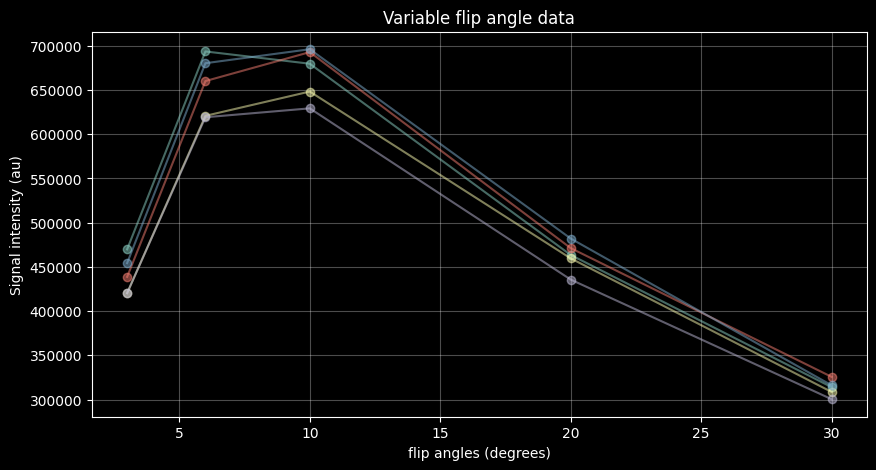

In [67]:
# Here the signal intensities of some voxels inside the tumor are plotted to give an impression what the data looks like.

fig, ax = plt.subplots(figsize=(10, 5))

# Sample tissue voxels; these are just hardcoded in this example, based on the location of the tumor identified in 3D Slicer
sample_indices = np.array(
    [[92, 104, 14], [89, 111, 14], [87, 111, 14], [82, 111, 14], [81, 108, 14]]
)
n_samples = len(sample_indices)
print(n_samples)
for i in range(n_samples):
    x, y, z = sample_indices[i][0], sample_indices[i][1], sample_indices[i][2]
    ax.plot(
        vfa_data.acquisition_params.flip_angles,
        vfa_data.data[x, y, z, :],
        marker="o",
        alpha=0.5,
    )

ax.set_xlabel("flip angles (degrees)")
ax.set_ylabel("Signal intensity (au)")
ax.set_title("Variable flip angle data")
ax.grid(True, alpha=0.3)

plt.savefig("t1_fitting.png", dpi=150)
plt.show()

In [65]:
# Compute T1 map using Variable Flip Angle method
t1_result = osipy.compute_t1_map(vfa_data, method="vfa")

# The result is a T1MappingResult with t1_map (ParameterMap) and quality_mask
t1_values = t1_result.t1_map.values
t1_quality = t1_result.quality_mask

print(f"T1 map shape: {t1_values.shape}")
print(
    f"T1 range: {t1_values[t1_quality > 0].min():.0f} - {t1_values[t1_quality > 0].max():.0f} ms"
)

T1 map shape: (176, 176, 30)
T1 range: 14 - 9998 ms


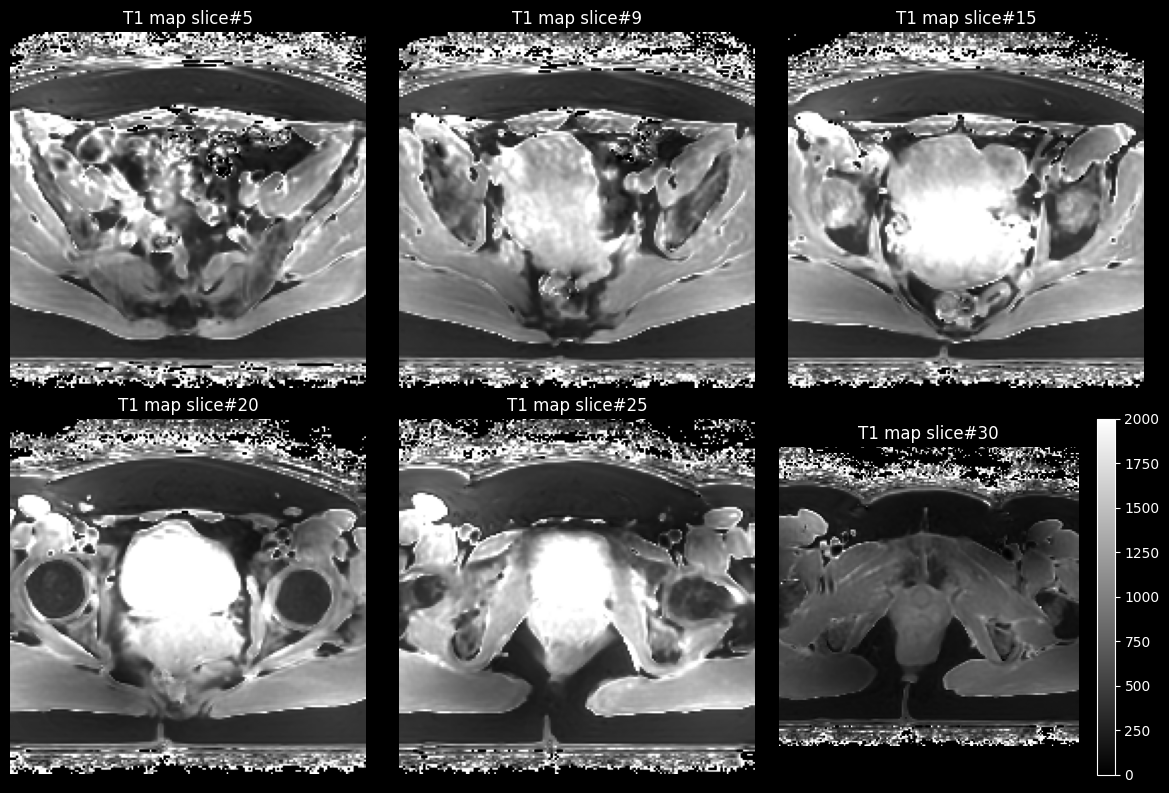

In [66]:
# visualize T1 map for some representative slices for a quick quality check
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# slice 12
im0 = axes[0, 0].imshow(
    np.transpose(t1_values[:, :, 4]), cmap="gray", vmin=0, vmax=2000
)
axes[0, 0].set_title("T1 map slice#5")
# slice 13
im0 = axes[0, 1].imshow(
    np.transpose(t1_values[:, :, 9]), cmap="gray", vmin=0, vmax=2000
)
axes[0, 1].set_title("T1 map slice#9")
# slice 14
im0 = axes[0, 2].imshow(
    np.transpose(t1_values[:, :, 14]), cmap="gray", vmin=0, vmax=2000
)
axes[0, 2].set_title("T1 map slice#15")
# slice 15
im0 = axes[1, 0].imshow(
    np.transpose(t1_values[:, :, 19]), cmap="gray", vmin=0, vmax=2000
)
axes[1, 0].set_title("T1 map slice#20")
# slice 16
im0 = axes[1, 1].imshow(
    np.transpose(t1_values[:, :, 24]), cmap="gray", vmin=0, vmax=2000
)
axes[1, 1].set_title("T1 map slice#25")
# slice 17
im0 = axes[1, 2].imshow(
    np.transpose(t1_values[:, :, 29]), cmap="gray", vmin=0, vmax=2000
)
axes[1, 2].set_title("T1 map slice#30")
plt.colorbar(im0, ax=axes[1, 2])
for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig("t1_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
# save T1 map as nifti for import in image visualization tools.
from osipy.common.io import save_nifti

OUT = "C://Temp//ISMRM2026_demo_DCE//osipy_output"
save_nifti(
    t1_values,
    OUT + "//t1map.nii.gz",
    affine=vfa_data.affine,
)

WindowsPath('C:/Temp/nki2025_DCEonly/osipy_output/t1map.nii.gz')

## Step 3: Create a Tissue Mask

In [34]:
# Simple threshold-based mask to exclude voxels without any contrast signal. This speeds up the fitting and improves the reliability of the output. This is an optional step and might require adjustment based on the dataset quality.Use the mean DCE signal to identify tissue (data accesses the raw array)

mean_signal = dce_data.data.mean(axis=-1)
signal_threshold = mean_signal.max() * 0.05  # 5% of max

# Combine with T1 quality
mask = (mean_signal > signal_threshold) & (t1_quality > 0)

# Optionally: exclude CSF (very high T1)
mask = mask & (t1_values < 3000)

print(f"Tissue voxels: {mask.sum()} / {mask.size}")

Tissue voxels: 705612 / 929280


## Step 4: Convert Signal to Concentration

DCE-MRI data are typically acquired with spoiled gradient recalled echo sequences (SPGR). The measured signal intensities can be converted to concentration values using the spoiled gradient echo equation as described in Schabel et al. (Phys Med Biol 2008):

$$
    S(T_1,T_2^*) = M_0 \cdot \frac{\mathrm{sin}(\alpha)(1 - e^{-\mathrm{TR}/T_1}) \cdot e^{-\mathrm{TE}/T_2^*}}{1 - e^{-\mathrm{TR}/T_1} \cdot \mathrm{cos}(\alpha)}
$$

with $S$ the measured signal intensity for spoiled gradient echo sequences, $T_1$, the longitudinal relaxation time, $T_2^*$ the transverse effective relaxation time,  $\alpha$ the flip angle, TR, the repitition time, and TE the echo time.

By making several simplifications (e.g. $T_2^*$ is negligible) the relative signal enhancement ($\Xi$) can be expressed as (eq 5 in Schabel et al):

$$
\Xi \approx \frac{(E_1 - E_{1,0})(\mathrm{cos}(\alpha)-1)}{(E_{1,0} - 1)(E_1 \mathrm{cos}(\alpha) -1)}
$$

where $E_{1,0} = e^{-\mathrm{TR}R_{1,0}}$ and $E_{1} = e^{-\mathrm{TR}R_{1}}$, $R_1 = 1/T_1$

In this way R_1 can be solved to obtain a nonlinear approximation as (eq 6 in Schabel et al):

$$
R_1^{nl} \approx - \frac{1}{\mathrm{TR}} \cdot \mathrm{log}[\frac{\Xi(E_{1,0} - 1) + E_{1,0}(1- \mathrm{cos}(\alpha))}{1+\mathrm{cos}(\alpha)(\Xi(E_{1,0} - 1)-1)}]
$$

This leads to a nonlinear approximation of the the concentration $C$ (eq 7 in Schabel et al):

$$
C^{nl} \approx \frac{1}{r_1}(R_1^{nl} - R_{1,0})
$$

with $r_1$ is the relaxivity of the contrast agent being used.

**important input parameters to be adjusted per study**
- relaxivity: the relaxivity parameters of the contrast agent used, e.g. in Rohrer et al (Invest Radiol 2005) or Sasaki et al (Magn Reson Med Sci 2005)
- baseline_frames: the number of baseline frames before contrast was injected.

In [54]:
from osipy.dce import DCEAcquisitionParams

# Define acquisition parameters
acq_params = DCEAcquisitionParams(
    tr=dce_data.acquisition_params.tr,  # ms
    te=dce_data.acquisition_params.te,  # ms
    flip_angles=[dce_data.acquisition_params.flip_angle],  # degrees (DCE flip angle)
    baseline_frames=5,
    relaxivity=3.4,  # mM^-1 s^-1 — Gd-DTPA in water at 3T
    # (Sasaki et al 2005, PMID 16462135: R1_3T_water=4.50).
    # In vivo plasma r1 at 3T is lower; override for
    # agent-specific in-vivo accuracy.
)

# Convert signal to concentration
# dce_signal_to_concentration wraps signal_to_concentration from osipy.dce
concentration = osipy.dce_signal_to_concentration(
    signal=dce_data.data,
    t1_map=t1_result.t1_map,
    acquisition_params=acq_params,
)

print(f"Concentration shape: {concentration.shape}")

# Check concentration range
valid_conc = concentration[mask]
print(f"Concentration range: {valid_conc.min():.3f} - {valid_conc.max():.3f} mM")

Concentration shape: (176, 176, 30, 65)
Concentration range: 0.000 - 1128.450 mM


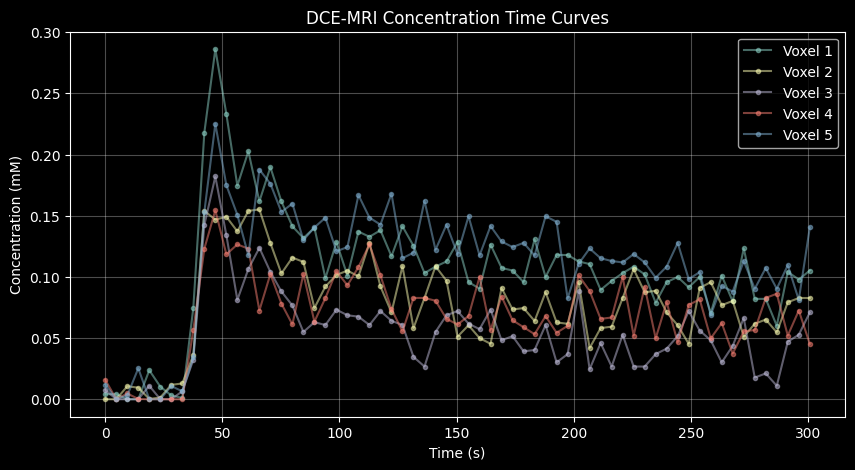

In [59]:
# visualize some concentration curves, using same voxel indices as for T1 mapping
fig, ax = plt.subplots(figsize=(10, 5))


for i in range(n_samples):
    x, y, z = sample_indices[i][0], sample_indices[i][1], sample_indices[i][2]
    ax.plot(
        time, concentration[x, y, z, :], marker=".", alpha=0.5, label=f"Voxel {i + 1}"
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Concentration (mM)")
ax.set_title("DCE-MRI Concentration Time Curves")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("dce_time_curves.png", dpi=150)
plt.show()

## Step 5: Select an Arterial Input Function

The AIF describes contrast agent concentration in blood plasma. OSIPY supports different population AIFs. In this example we use the Parker AIF, which is a widely used population average for in vivo data.

In [36]:
# Parker AIF - widely used population average for in vivo data. Mul
# Derived from 23 abdominal cancer patients at 1.5T receiving gadodiamide
# (Parker 2006, PMID 17036301). Use with caution at 3T, in brain/head-and-neck,
# or with different contrast agents — consider a measured or study-matched AIF
# when those conditions differ.
aif = osipy.ParkerAIF()(time)

print(
    f"AIF peak: {aif.concentration.max():.2f} mM at {time[aif.concentration.argmax()]:.1f} s"
)

AIF peak: 5.85 mM at 9.4 s


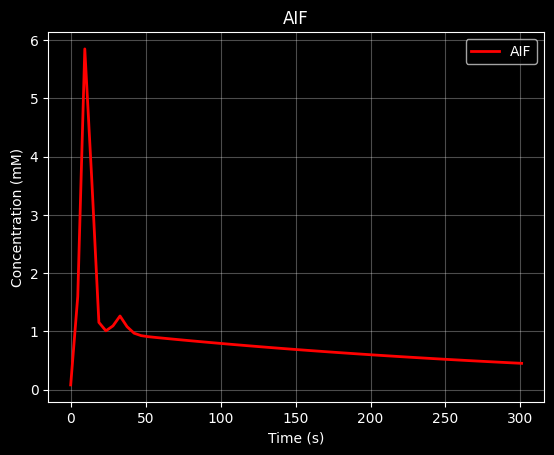

In [42]:
# Plot the AIF time curve
import matplotlib.pyplot as plt

plt.plot(time, aif.concentration, "r-", linewidth=2, label="AIF")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mM)")
plt.title("AIF")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Step 6: Fit the pharmacokinetic model

OSIPY supports different pharmacokinetic models. The model choice depends on the acquisition protocol as well as the application. For more information on the theory behind the models we refer to the paper of Sourbron and Buckley (NMR biomed 2013).

**Input parameters to consider**
- model choice: which model fits best with your data and application
- aif choice: see above
- fit_delay: this is needed when the data contains baseline data as in this example. This option includes the delay as a fitting parameter. Without this option, there will be a mismatch with the timing of the AIF and the DCE curves.

In [37]:
# Fit Extended Tofts model
result = osipy.fit_model(
    "extended_tofts",
    concentration=concentration,
    aif=aif,
    time=time,
    mask=mask,
    fit_delay=True,
)

# Extract parameter maps (result is a DCEFitResult object)
ktrans = result.parameter_maps["Ktrans"].values
ve = result.parameter_maps["ve"].values
vp = result.parameter_maps["vp"].values
r_squared = result.r_squared_map
quality_mask = result.quality_mask

# Statistics on valid voxels
valid = quality_mask
print(f"\nFitting Results (valid voxels: {valid.sum()}):")
print(f"  Ktrans: {ktrans[valid].mean():.4f} ± {ktrans[valid].std():.4f} min⁻¹")
print(f"  ve:     {ve[valid].mean():.4f} ± {ve[valid].std():.4f}")
print(f"  vp:     {vp[valid].mean():.4f} ± {vp[valid].std():.4f}")
print(f"  R²:     {r_squared[valid].mean():.4f} ± {r_squared[valid].std():.4f}")


Fitting Results (valid voxels: 705612):
  Ktrans: 0.1043 ± 0.1963 min⁻¹
  ve:     0.3469 ± 0.3516
  vp:     0.0088 ± 0.0414
  R²:     0.3819 ± 0.3483


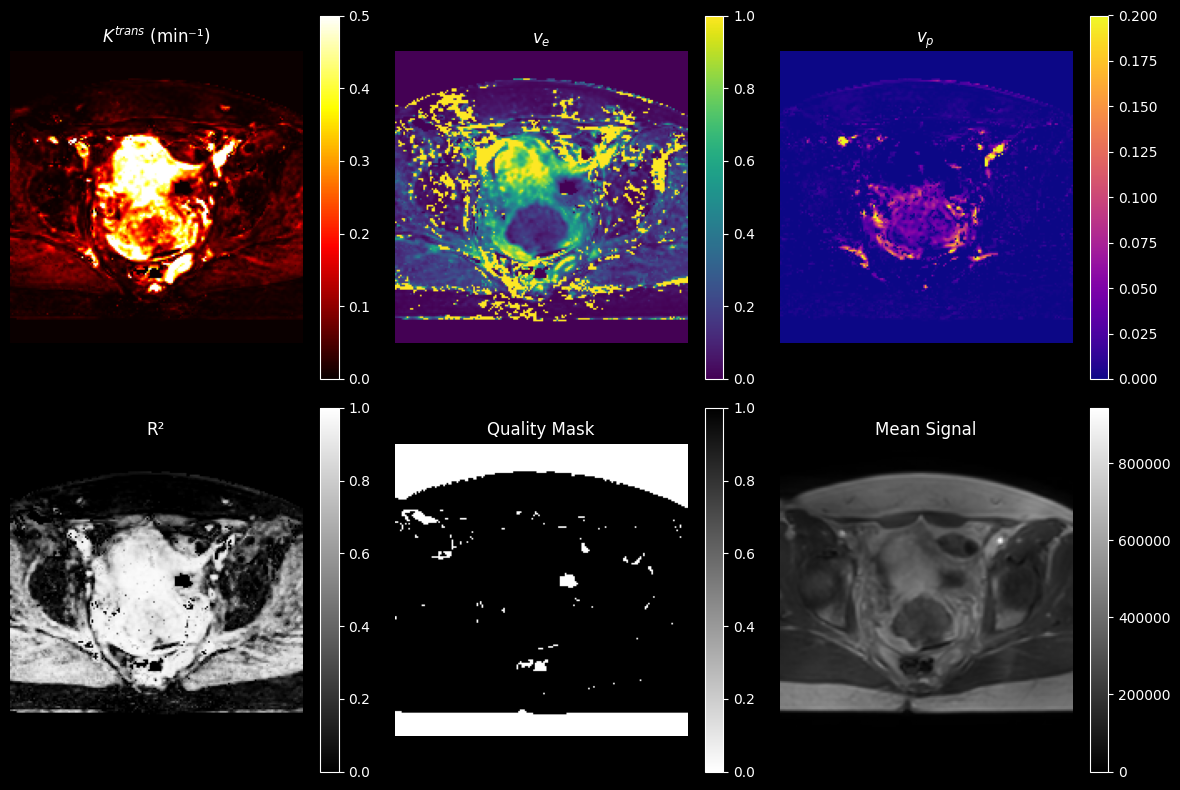

In [38]:
# visualize results

import matplotlib.pyplot as plt

# Select a representative slice
slice_idx = dce_data.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Row 1: Parameter maps
im0 = axes[0, 0].imshow(
    np.transpose(ktrans[:, :, slice_idx]), cmap="hot", vmin=0, vmax=0.5
)
axes[0, 0].set_title("$K^{trans}$ (min⁻¹)")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(
    np.transpose(ve[:, :, slice_idx]), cmap="viridis", vmin=0, vmax=1
)
axes[0, 1].set_title("$v_e$")
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].imshow(
    np.transpose(vp[:, :, slice_idx]), cmap="plasma", vmin=0, vmax=0.2
)
axes[0, 2].set_title("$v_p$")
plt.colorbar(im2, ax=axes[0, 2])

# Row 2: Quality metrics
im3 = axes[1, 0].imshow(
    np.transpose(r_squared[:, :, slice_idx]), cmap="gray", vmin=0, vmax=1
)
axes[1, 0].set_title("R²")
plt.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(np.transpose(quality_mask[:, :, slice_idx]), cmap="binary")
axes[1, 1].set_title("Quality Mask")
plt.colorbar(im4, ax=axes[1, 1])

# Anatomy reference
im5 = axes[1, 2].imshow(np.transpose(mean_signal[:, :, slice_idx]), cmap="gray")
axes[1, 2].set_title("Mean Signal")
plt.colorbar(im5, ax=axes[1, 2])

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig("dce_parameter_maps.png", dpi=300, bbox_inches="tight")
plt.show()

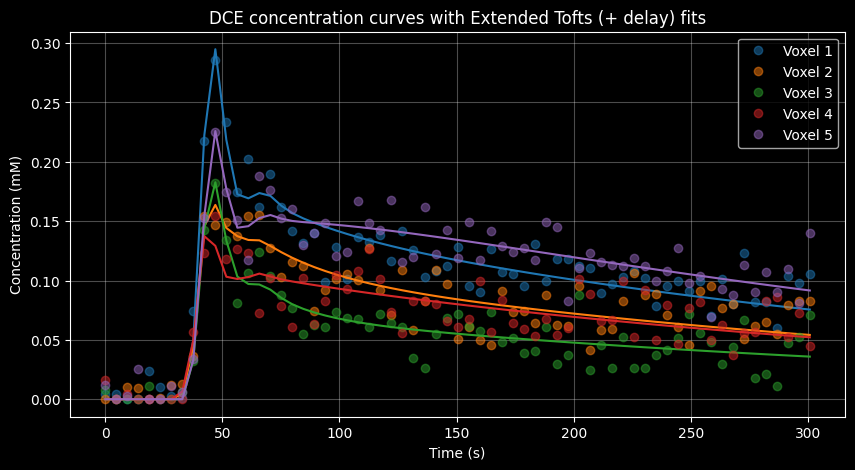

In [75]:
# Overlay measured concentrations with model fits
from osipy.dce.fitting import _DelayAwareModel
from osipy.dce.models import ExtendedToftsModel

model = _DelayAwareModel(ExtendedToftsModel())
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(n_samples):
    x, y, z = sample_indices[i]

    params = {
        "Ktrans": result.parameter_maps["Ktrans"].values[x, y, z],
        "ve": result.parameter_maps["ve"].values[x, y, z],
        "vp": result.parameter_maps["vp"].values[x, y, z],
        "delay": result.parameter_maps["delay"].values[x, y, z],
    }
    params_arr = model.params_to_array(params)
    fitted = model.predict(time, aif.concentration, params_arr, np)

    c = colors[i % len(colors)]
    ax.plot(
        time, concentration[x, y, z, :], "o", color=c, alpha=0.5, label=f"Voxel {i + 1}"
    )
    ax.plot(time, fitted, "-", color=c)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Concentration (mM)")
ax.set_title("DCE concentration curves with Extended Tofts (+ delay) fits")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("dce_curve_fits.png", dpi=150)
plt.show()

### References

Deoni et al “High-resolution T1 and T2 mapping of the brain in a clinically acceptable time with DESPOT1 and DESPOT2” Magn Reson Med, 2005; 53(1):237-41. doi: 10.1002/mrm.20314

Fram et al. “Rapid calculation of T1 using variable flip angle gradient refocused imaging” Magn Reson Imaging, 1987;5(3):201-8. doi: 10.1016/0730-725x(87)90021-x

Parker et al. Experimentally-Derived Functional Form for a Population-Averaged High-Temporal-Resolution Arterial Input Function for Dynamic Contrast-Enhanced MRI. Magnetic Resonance in Medicine 56:993–1000 (2006); DOI 10.1002/mrm.21066

Rohrer et al. "Comparison of magnetic properties of MRI contrast media solutions at different magnetic field strengths". Invest Radiol. 2005 Nov;40(11):715-24. doi: 10.1097/01.rli.0000184756.66360.d3.

Sasaki M et al. "Enhancement effects and relaxivities of gadolinium-DTPA at 1.5 versus 3 Tesla: a phantom study". Magn Reson Med Sci. 2005;4(3):145-9. doi: 10.2463/mrms.4.145.

Schabel MC and Parker DL “Uncertainty and bias in contrast concentration measurements using spoiled gradient echo pulse sequences” Phys Med Biol (2008), doi:10.1088/0031-9155/53/9/010

Sourbron SP and Buckley DL. "Classic models for dynamic contrast-enhanced MRI". NMR Biomed. 2013 Aug;26(8):1004-27. doi: 10.1002/nbm.2940.